# Flight Delay Prediction

## Problem Statement :

The goal of this project is to predict whether a flight will be delayed before its scheduled departure time using historical flight data.

---

## Analytical Questions

- Does the airline affect the likelihood of delay?  
- Does departure time influence delays?  
- Are certain days of the week more prone to delays?  
- Does flight distance impact delay probability?  
- Do specific airports (origin/destination) have higher delay rates?  

In [2]:
import pandas as pd

df = pd.read_parquet("Combined_Flights_2022.parquet")

In [3]:
df.head()


,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,False,False,1133,1123.0,0.0,-10.0,...,1140.0,1220.0,8.0,1245,-17.0,0.0,-2.0,1200-1259,1,0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,False,False,732,728.0,0.0,-4.0,...,744.0,839.0,9.0,849,-1.0,0.0,-1.0,0800-0859,2,0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1529,1514.0,0.0,-15.0,...,1535.0,1622.0,14.0,1639,-3.0,0.0,-1.0,1600-1659,2,0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,False,False,1435,1430.0,0.0,-5.0,...,1446.0,1543.0,4.0,1605,-18.0,0.0,-2.0,1600-1659,2,0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1135,1135.0,0.0,0.0,...,1154.0,1243.0,8.0,1245,6.0,0.0,0.0,1200-1259,2,0


In [4]:
df.shape

(4078318, 61)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4078318 entries, 0 to 590541
Data columns (total 61 columns):
 #   Column                                   Dtype         
---  ------                                   -----         
 0   FlightDate                               datetime64[us]
 1   Airline                                  object        
 2   Origin                                   object        
 3   Dest                                     object        
 4   Cancelled                                bool          
 5   Diverted                                 bool          
 6   CRSDepTime                               int64         
 7   DepTime                                  float64       
 8   DepDelayMinutes                          float64       
 9   DepDelay                                 float64       
 10  ArrTime                                  float64       
 11  ArrDelayMinutes                          float64       
 12  AirTime                           

### To ensure high-quality analysis, several columns were removed from the dataset.

### First, columns that introduce data leakage were eliminated. These columns contain information that is only available after the flight departure ###(such as actual departure time, arrival time, and delay details), which would lead to unrealistic predictions.

### Second, irrelevant and non-informative columns (e.g., flight numbers, tail numbers, and technical flags) were removed, as they do not contribute meaningful insights to the prediction task.

### Finally, redundant columns such as airline codes and network identifiers were dropped since they duplicate information already represented in the Airline column.

### This step helps simplify the dataset, reduce noise, and improve the efficiency of further analysis.
    

In [6]:

# 1. Columns causing leakage

leakage_cols = [
    'DepTime', 'DepDelayMinutes', 'DepartureDelayGroups',
    'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn',
    'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups',
    'ActualElapsedTime', 'AirTime',
    'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'
]


# 2. Columns not useful (Irrelevant)

not_useful = [
    'Tail_Number',
    'Flight_Number_Marketing_Airline',
    'Flight_Number_Operating_Airline',
    'Flight_Num_Originally_Scheduled_Code_Share_Airline',
    'Operated_or_Branded_Code_Share_Partners',
    'Originally_Scheduled_Code_Share_Airline',
    'IATA_Code_Originally_Scheduled_Code_Share_Airline',
    'Flights',
    'Duplicate',
    'FirstDepTime', 'TotalAddGTime', 'LongestAddGTime',
    'IATA_Code_Operating_Airline',
    'IATA_Code_Marketing_Airline',
    'Marketing_Airline_Network'
]


# 3. Redundant ID columns

redundant_ids = [
    'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID',
    'OriginStateFips', 'OriginWac',
    'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID',
    'DestStateFips', 'DestWac',
    'DOT_ID_Marketing_Airline', 'DOT_ID_Operating_Airline'
]


# 4. Drop all at once
df.drop(columns=leakage_cols + not_useful + redundant_ids,
        inplace=True,
        errors='ignore')



In [7]:
df.shape

(4078318, 29)

In [8]:
df.isnull().sum()

FlightDate                 0
Airline                    0
Origin                     0
Dest                       0
Cancelled                  0
Diverted                   0
CRSDepTime                 0
DepDelay              120495
CRSElapsedTime             0
Distance                   0
Year                       0
Quarter                    0
Month                      0
DayofMonth                 0
DayOfWeek                  0
Operating_Airline          0
OriginCityName             0
OriginState                0
OriginStateName            0
DestCityName               0
DestState                  0
DestStateName              0
DepDel15              120495
DepTimeBlk                 0
CRSArrTime                 0
ArrDel15              133402
ArrTimeBlk                 0
DistanceGroup              0
DivAirportLandings         0
dtype: int64

### Missing values were analyzed across the dataset.

### The ArrDel15 column was removed as it represents post-arrival information, which is not available at prediction time and may introduce data leakage.

### Rows with missing values in the target variables (DepDelay and DepDel15) were removed to ensure data reliability and consistency.

In [9]:
# Drop ArrDel15 (leakage)
df = df.drop(columns=['ArrDel15'], errors='ignore')

In [10]:
df.isnull().sum().sort_values(ascending=False)

DepDelay              120495
DepDel15              120495
Origin                     0
FlightDate                 0
Dest                       0
Cancelled                  0
Diverted                   0
CRSDepTime                 0
CRSElapsedTime             0
Distance                   0
Year                       0
Airline                    0
Quarter                    0
Month                      0
DayOfWeek                  0
DayofMonth                 0
OriginCityName             0
OriginState                0
OriginStateName            0
Operating_Airline          0
DestCityName               0
DestState                  0
DestStateName              0
DepTimeBlk                 0
CRSArrTime                 0
ArrTimeBlk                 0
DistanceGroup              0
DivAirportLandings         0
dtype: int64

In [11]:
# Remove rows where target variables are missing
df = df.dropna(subset=['DepDelay', 'DepDel15'])

In [12]:
df.isnull().sum()

FlightDate            0
Airline               0
Origin                0
Dest                  0
Cancelled             0
Diverted              0
CRSDepTime            0
DepDelay              0
CRSElapsedTime        0
Distance              0
Year                  0
Quarter               0
Month                 0
DayofMonth            0
DayOfWeek             0
Operating_Airline     0
OriginCityName        0
OriginState           0
OriginStateName       0
DestCityName          0
DestState             0
DestStateName         0
DepDel15              0
DepTimeBlk            0
CRSArrTime            0
ArrTimeBlk            0
DistanceGroup         0
DivAirportLandings    0
dtype: int64

### Duplicate rows were identified in the dataset, where identical flight records appeared more than once.

### Only a small number of duplicates (5 rows) were found, indicating minimal redundancy in the dataset.

### These duplicate rows were removed to ensure data consistency and prevent bias in further analysis.

In [13]:
df.duplicated().sum()

np.int64(5)

In [14]:
df[df.duplicated()]

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepDelay,CRSElapsedTime,Distance,...,OriginStateName,DestCityName,DestState,DestStateName,DepDel15,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,DivAirportLandings
63455,2022-05-31,SkyWest Airlines Inc.,SFO,LAX,False,False,600,-3.0,85.0,337.0,...,California,"Los Angeles, CA",CA,California,0.0,0600-0659,725,0700-0759,2,0
600221,2022-05-18,Republic Airlines,SDF,LGA,False,False,1236,-8.0,129.0,659.0,...,Kentucky,"New York, NY",NY,New York,0.0,1200-1259,1445,1400-1459,3,0
47430,2022-06-06,SkyWest Airlines Inc.,LAX,SFO,False,False,945,-2.0,83.0,337.0,...,California,"San Francisco, CA",CA,California,0.0,0900-0959,1108,1100-1159,2,0
50058,2022-06-03,SkyWest Airlines Inc.,SFO,LAX,False,False,600,-3.0,85.0,337.0,...,California,"Los Angeles, CA",CA,California,0.0,0600-0659,725,0700-0759,2,0
68894,2022-06-01,SkyWest Airlines Inc.,SFO,LAX,False,False,600,-4.0,85.0,337.0,...,California,"Los Angeles, CA",CA,California,0.0,0600-0659,725,0700-0759,2,0


In [15]:
df.drop_duplicates(inplace=True, keep='first')

In [16]:
df.duplicated().sum()

np.int64(0)

### Data types were reviewed to ensure consistency and correctness across the dataset.

### The DepDel15 column was converted from float to integer to properly represent binary classification values (0 or 1), which is essential for the prediction task.

### The FlightDate column was confirmed to be in datetime format to enable time-based analysis.

### Time-related columns such as CRSDepTime were kept in their original numeric format, as time block features (e.g., DepTimeBlk) provide a simpler and more interpretable representation of departure time.

### Additionally, binary columns such as Cancelled and Diverted were converted from boolean to integer format (0/1) to improve compatibility with machine learning models and reduce memory usage.

df.dtypes

In [17]:
df['DepDel15'] = df['DepDel15'].astype(int)

In [18]:
df.dtypes

FlightDate            datetime64[us]
Airline                       object
Origin                        object
Dest                          object
Cancelled                       bool
Diverted                        bool
CRSDepTime                     int64
DepDelay                     float64
CRSElapsedTime               float64
Distance                     float64
Year                           int64
Quarter                        int64
Month                          int64
DayofMonth                     int64
DayOfWeek                      int64
Operating_Airline             object
OriginCityName                object
OriginState                   object
OriginStateName               object
DestCityName                  object
DestState                     object
DestStateName                 object
DepDel15                       int64
DepTimeBlk                    object
CRSArrTime                     int64
ArrTimeBlk                    object
DistanceGroup                  int64
D

In [19]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors='coerce')

In [20]:
df.dtypes

FlightDate            datetime64[us]
Airline                       object
Origin                        object
Dest                          object
Cancelled                       bool
Diverted                        bool
CRSDepTime                     int64
DepDelay                     float64
CRSElapsedTime               float64
Distance                     float64
Year                           int64
Quarter                        int64
Month                          int64
DayofMonth                     int64
DayOfWeek                      int64
Operating_Airline             object
OriginCityName                object
OriginState                   object
OriginStateName               object
DestCityName                  object
DestState                     object
DestStateName                 object
DepDel15                       int64
DepTimeBlk                    object
CRSArrTime                     int64
ArrTimeBlk                    object
DistanceGroup                  int64
D

In [21]:
binary_cols=["Cancelled","Diverted"]
df[binary_cols]=df[binary_cols].astype('int8')

### The DepDelay column was split into Delay_Minutes and Early_Minutes to clearly separate delay and early departure behavior.

### The original column was then removed to avoid redundancy.

In [22]:
df['Delay_Minutes'] = df['DepDelay'].clip(lower=0)
df['Early_Minutes'] = df['DepDelay'].clip(upper=0).abs()

In [23]:
df = df.drop(columns=['DepDelay'])

In [24]:
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,CRSElapsedTime,Distance,Year,...,DestState,DestStateName,DepDel15,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,DivAirportLandings,Delay_Minutes,Early_Minutes
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,0,0,1133,72.0,212.0,2022,...,CO,Colorado,0,1100-1159,1245,1200-1259,1,0,0.0,10.0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,0,0,732,77.0,295.0,2022,...,TX,Texas,0,0700-0759,849,0800-0859,2,0,0.0,4.0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,0,0,1529,70.0,251.0,2022,...,CO,Colorado,0,1500-1559,1639,1600-1659,2,0,0.0,15.0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,0,0,1435,90.0,376.0,2022,...,MS,Mississippi,0,1400-1459,1605,1600-1659,2,0,0.0,5.0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,0,0,1135,70.0,251.0,2022,...,CO,Colorado,0,1100-1159,1245,1200-1259,2,0,0.0,0.0


In [25]:
df.shape

(3957818, 29)

### Outliers were removed by filtering extreme delay values above 500 minutes. 
### The remaining data still shows a right-skewed distribution, which is expected since most flights have little to no delay while a small number experience larger delays.

In [26]:
df['Delay_Minutes'].describe()

count    3.957818e+06
mean     1.601496e+01
std      5.231501e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.100000e+01
max      7.223000e+03
Name: Delay_Minutes, dtype: float64

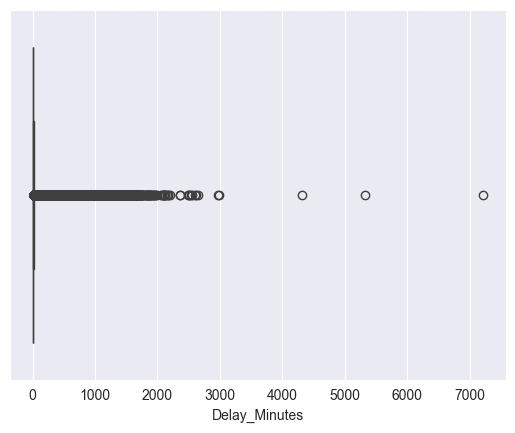

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Delay_Minutes'])
plt.show()

In [28]:
df = df[df['Delay_Minutes'] < 500]
df = df[df['Early_Minutes'] < 200]

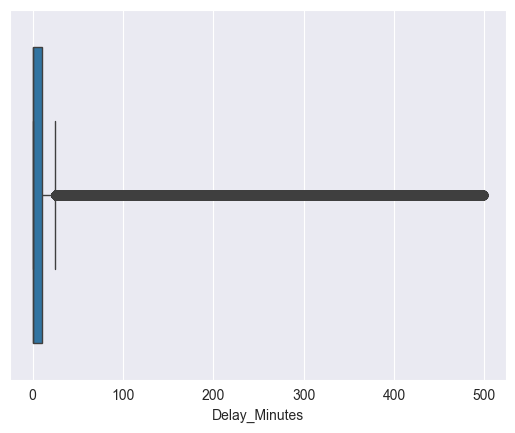

In [29]:
df['Delay_Minutes'].describe()
sns.boxplot(x=df['Delay_Minutes'])
plt.show()

### The cleaned dataset is saved to both Parquet and CSV formats.

In [30]:
# Save the cleaned dataset
output_parquet = "cleaned_flights_2022.parquet"
output_csv = "cleaned_flights_2022.csv"

df.to_parquet(output_parquet, index=False)
df.to_csv(output_csv, index=False)

print(f"Saved {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Parquet -> {output_parquet}")
print(f"CSV     -> {output_csv}")

Saved 3,951,046 rows x 29 columns
Parquet -> cleaned_flights_2022.parquet
CSV     -> cleaned_flights_2022.csv
